<p align="right">
  <img src="Zewail-City.png">
</p>


---

# __Problem set #7__

In [1]:
# Mian Libraries
import os
import time
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.optimize import minimize
from scipy.special import erf
from concurrent.futures import ThreadPoolExecutor, as_completed
from threading import Lock

In [2]:
# Set random seed for reproducibility
np.random.seed(42)

### Problem 1: Local vs Global Significance

In [3]:
# Given data
search_range = 150 - 110  # GeV
mass_resolution = 2  # GeV
Z_local = 4.1  # sigma

# Estimate effective number of trials
N_eff = search_range / mass_resolution
print(f"\n1. Effective number of trials:")
print(f"   N_eff = (search range) / (mass resolution)")
print(f"   N_eff = {search_range} GeV / {mass_resolution} GeV = {N_eff}")


1. Effective number of trials:
   N_eff = (search range) / (mass resolution)
   N_eff = 40 GeV / 2 GeV = 20.0


In [4]:
# Approximate global p-value
# compute local p-value from Z_local
p_local = 1 - stats.norm.cdf(Z_local)
print(f"\n2. Local p-value:")
print(f"   p_local = 1 - Φ(Z_local) = 1 - Φ({Z_local})")
print(f"   p_local = {p_local:.6e}")

# Global p-value using trials factor approximation
p_global = N_eff * p_local
print(f"\n   Global p-value (trials factor approximation):")
print(f"   p_global ≈ N_eff × p_local")
print(f"   p_global ≈ {N_eff} × {p_local:.6e}")
print(f"   p_global ≈ {p_global:.6e}")


2. Local p-value:
   p_local = 1 - Φ(Z_local) = 1 - Φ(4.1)
   p_local = 2.065751e-05

   Global p-value (trials factor approximation):
   p_global ≈ N_eff × p_local
   p_global ≈ 20.0 × 2.065751e-05
   p_global ≈ 4.131501e-04


In [5]:
# Convert to global significance
Z_global = stats.norm.ppf(1 - p_global)
print(f"\n3. Global significance:")
print(f"   Z_global = Φ^(-1)(1 - p_global)")
print(f"   Z_global = {Z_global:.2f}σ")


3. Global significance:
   Z_global = Φ^(-1)(1 - p_global)
   Z_global = 3.34σ


In [6]:
print(f"\n   Summary:")
print(f"   - Local significance:  {Z_local:.2f}σ")
print(f"   - Global significance: {Z_global:.2f}σ")
print(f"   - Reduction due to LEE: {Z_local - Z_global:.2f}σ")


   Summary:
   - Local significance:  4.10σ
   - Global significance: 3.34σ
   - Reduction due to LEE: 0.76σ


---

### Problem 2: CLs Exclusion

In [7]:
# Given p-values
p_sb = 0.08  # p-value under signal + background
p_b = 0.30   # p-value under background only

# Compute CLs
CL_s = p_sb / (1 - p_b)
print(f"\nTesting signal hypothesis with μ = 1")
print(f"\nGiven:")
print(f"   p_s+b = {p_sb}")
print(f"   p_b   = {p_b}")

print(f"\n1. Computing CLs:")
print(f"   CLs = p_s+b / (1 - p_b)")
print(f"   CLs = {p_sb} / (1 - {p_b})")
print(f"   CLs = {p_sb} / {1 - p_b}")
print(f"   CLs = {CL_s:.4f}")


Testing signal hypothesis with μ = 1

Given:
   p_s+b = 0.08
   p_b   = 0.3

1. Computing CLs:
   CLs = p_s+b / (1 - p_b)
   CLs = 0.08 / (1 - 0.3)
   CLs = 0.08 / 0.7
   CLs = 0.1143


In [8]:
# Is signal excluded at 95% CL?
exclusion_threshold = 0.05
is_excluded = CL_s < exclusion_threshold

print(f"\n2. Exclusion test at 95% CL:")
print(f"   Exclusion criterion: CLs < 0.05")
print(f"   CLs = {CL_s:.4f}")
print(f"   {CL_s:.4f} < 0.05? {is_excluded}")

if is_excluded:
    print(f"\n    Signal is EXCLUDED at 95% CL")
else:
    print(f"\n    Signal is NOT excluded at 95% CL")


2. Exclusion test at 95% CL:
   Exclusion criterion: CLs < 0.05
   CLs = 0.1143
   0.1143 < 0.05? False

    Signal is NOT excluded at 95% CL


> **Interpretation**:
  The CLs method avoids excluding signals to which the experiment has little sensitivity. Since CLs = 0.1143 > 0.05,   we cannot exclude this signal hypothesis at 95% confidence level.

---

### Problem 3: Channel Combination

In [9]:
# Given significances
Z1 = 3.8  # sigma, channel 1
Z2 = 4.5  # sigma, channel 2

print(f"\nTwo independent channels:")
print(f"   Channel 1: Z₁ = {Z1}σ")
print(f"   Channel 2: Z₂ = {Z2}σ")


Two independent channels:
   Channel 1: Z₁ = 3.8σ
   Channel 2: Z₂ = 4.5σ


In [10]:
# Method 1: Proper combination using log-likelihood ratios
print(f"\n1. Proper combination (adding log-likelihood ratios):")
print(f"   Under Wilks' theorem: q₀ = Z²")

q0_1 = Z1**2
q0_2 = Z2**2
q0_combined = q0_1 + q0_2
Z_combined = np.sqrt(q0_combined)

print(f"   q₀,₁ = Z₁² = {Z1}² = {q0_1:.2f}")
print(f"   q₀,₂ = Z₂² = {Z2}² = {q0_2:.2f}")
print(f"   q₀,combined = q₀,₁ + q₀,₂ = {q0_1:.2f} + {q0_2:.2f} = {q0_combined:.2f}")
print(f"   Z_combined = √(q₀,combined) = √{q0_combined:.2f} = {Z_combined:.2f}σ")


1. Proper combination (adding log-likelihood ratios):
   Under Wilks' theorem: q₀ = Z²
   q₀,₁ = Z₁² = 3.8² = 14.44
   q₀,₂ = Z₂² = 4.5² = 20.25
   q₀,combined = q₀,₁ + q₀,₂ = 14.44 + 20.25 = 34.69
   Z_combined = √(q₀,combined) = √34.69 = 5.89σ


In [11]:
# Method 2: Quadrature approximation (incorrect but often used)
print(f"\n2. Quadrature approximation (for comparison):")
Z_quadrature = np.sqrt(Z1**2 + Z2**2)
print(f"   Z_quad = √(Z₁² + Z₂²) = √({Z1}² + {Z2}²)")
print(f"   Z_quad = √({Z1**2:.2f} + {Z2**2:.2f}) = {Z_quadrature:.2f}σ")


2. Quadrature approximation (for comparison):
   Z_quad = √(Z₁² + Z₂²) = √(3.8² + 4.5²)
   Z_quad = √(14.44 + 20.25) = 5.89σ


In [12]:
print(f"\n   Comparison:")
print(f"   - Proper combination (adding q₀): {Z_combined:.2f}σ")
print(f"   - Quadrature approximation:       {Z_quadrature:.2f}σ")
print(f"   - Difference:                     {abs(Z_combined - Z_quadrature):.2f}σ")


   Comparison:
   - Proper combination (adding q₀): 5.89σ
   - Quadrature approximation:       5.89σ
   - Difference:                     0.00σ


In [13]:
print(f"\n   Note: Both methods give the same result because we're in the")
print(f"   asymptotic regime where q₀ = Z². The proper method is to add")
print(f"   the test statistics (q₀ values), which is equivalent to adding")
print(f"   squared significances.")


   Note: Both methods give the same result because we're in the
   asymptotic regime where q₀ = Z². The proper method is to add
   the test statistics (q₀ values), which is equivalent to adding
   squared significances.


In [14]:
# Convert to p-values to show significance
p_combined = 1 - stats.norm.cdf(Z_combined)
print(f"\n   Combined p-value: {p_combined:.2e}")
print(f"   This corresponds to a {Z_combined:.2f}σ observation.")


   Combined p-value: 1.93e-09
   This corresponds to a 5.89σ observation.


---

### Problem 4: Mini Higgs Search and the Look-Elsewhere Effect

In [15]:
# ============================================================================
# Part A: Data Generation and Likelihood Construction
# ============================================================================

# Physics parameters
m_min, m_max = 110, 150  # GeV
sigma_signal = 1.5  # GeV
m_true = 125.0  # True Higgs mass (for data generation)
mu_true = 1.0  # True signal strength

# Generate background and signal
N_background = 10000
N_signal = 180

# Generate from exponential and SUBTRACT from max to get falling distribution
background_raw = np.random.exponential(scale=15, size=N_background)
background_events = m_max - background_raw
background_events = background_events[(background_events >= m_min) & (background_events <= m_max)]

# Signal: Gaussian around true Higgs mass
signal_events = np.random.normal(m_true, sigma_signal, N_signal)
signal_events = signal_events[(signal_events >= m_min) & (signal_events <= m_max)]

# Combine
data = np.concatenate([background_events, signal_events])
data = data[(data >= m_min) & (data <= m_max)]
N_obs = len(data)

In [16]:
print(f"\nGenerated dataset:")
print(f"   Background events: {len(background_events)}")
print(f"   Signal events:     {len(signal_events)}")
print(f"   Total observed:    {N_obs}")
print(f"   Mass range:        [{m_min}, {m_max}] GeV")

print(f"\nTrue parameters (unknown to the analysis):")
print(f"   True Higgs mass:      m_H = {m_true} GeV")
print(f"   True signal strength: μ = {mu_true}")


Generated dataset:
   Background events: 9303
   Signal events:     180
   Total observed:    9483
   Mass range:        [110, 150] GeV

True parameters (unknown to the analysis):
   True Higgs mass:      m_H = 125.0 GeV
   True signal strength: μ = 1.0


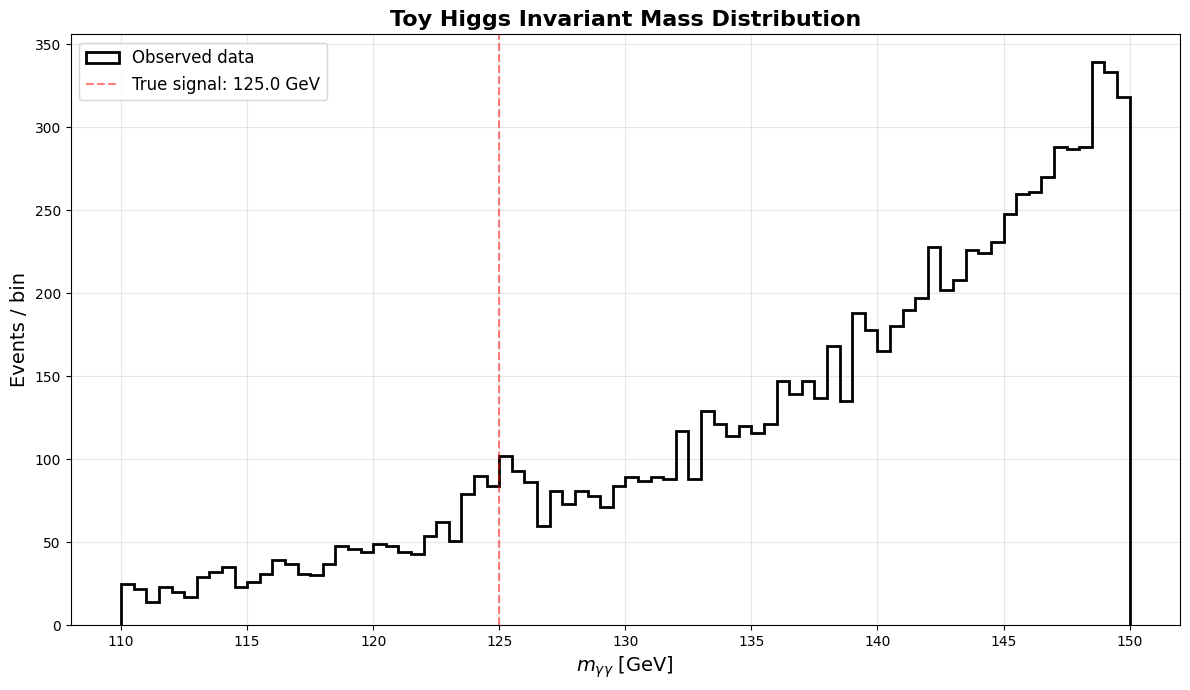

In [17]:
# Plot the invariant mass distribution
plt.figure(figsize=(12, 7))
plt.hist(data, bins=80, range=(m_min, m_max), histtype='step', 
         linewidth=2, color='black', label='Observed data')
plt.axvline(m_true, color='red', linestyle='--', alpha=0.5, label=f'True signal: {m_true} GeV')
plt.xlabel(r'$m_{\gamma\gamma}$ [GeV]', fontsize=14)
plt.ylabel('Events / bin', fontsize=14)
plt.title('Toy Higgs Invariant Mass Distribution', fontsize=16, fontweight='bold')
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('problem4_mass_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

In [18]:
# Likelihood construction
print(f"\nLikelihood construction:")
print(f"\nUnbinned extended likelihood:")
print(f"   L(μ, m_H, ν) = exp[-(μS + B)] × ∏ᵢ[μS·f_S(mᵢ|m_H,σ) + B·f_B(mᵢ|ν)]")
print(f"\nWhere:")
print(f"   • μ:   signal strength (parameter of interest)")
print(f"   • m_H: signal mass hypothesis (scanned parameter)")
print(f"   • S:   expected signal yield")
print(f"   • B:   background yield (nuisance parameter)")
print(f"   • f_S: signal PDF = Gaussian(m_H, σ={sigma_signal} GeV)")
print(f"   • f_B: background PDF = exponential(λ) [nuisance parameter λ]")
print(f"   • ν:   nuisance parameters = {{B, λ}}")

print(f"\nParameters classification:")
print(f"   Parameter of interest: μ (signal strength)")
print(f"   Nuisance parameters:   B (background yield), λ (background shape)")
print(f"   Scanned hypothesis:    m_H (tested at multiple values)")


Likelihood construction:

Unbinned extended likelihood:
   L(μ, m_H, ν) = exp[-(μS + B)] × ∏ᵢ[μS·f_S(mᵢ|m_H,σ) + B·f_B(mᵢ|ν)]

Where:
   • μ:   signal strength (parameter of interest)
   • m_H: signal mass hypothesis (scanned parameter)
   • S:   expected signal yield
   • B:   background yield (nuisance parameter)
   • f_S: signal PDF = Gaussian(m_H, σ=1.5 GeV)
   • f_B: background PDF = exponential(λ) [nuisance parameter λ]
   • ν:   nuisance parameters = {B, λ}

Parameters classification:
   Parameter of interest: μ (signal strength)
   Nuisance parameters:   B (background yield), λ (background shape)
   Scanned hypothesis:    m_H (tested at multiple values)


In [19]:
# ============================================================================
# Part B: Local Significance Scan
# ============================================================================

# Define PDFs
def signal_pdf(m, m_H, sigma):
    """Gaussian signal PDF"""
    return (1 / (np.sqrt(2 * np.pi) * sigma)) * np.exp(-0.5 * ((m - m_H) / sigma)**2)

def background_pdf(m, lam, m_max):
    """FALLING exponential: high at low mass, low at high mass"""
    return lam * np.exp(-lam * (m_max - m))

def negative_log_likelihood(params, data, m_H, sigma, m_max):
    """NLL for signal + background"""
    mu = params[0]   # signal strength
    B = params[1]    # background yield
    lam = params[2]  # background shape
    
    if mu < 0 or B < 0 or lam <= 0 or mu > 3:
        return 1e10
    
    S = 180.0  # Expected signal
    extended_term = -(mu * S + B)
    
    event_term = 0
    for m in data:
        fs = signal_pdf(m, m_H, sigma)
        fb = background_pdf(m, lam, m_max)
        prob = mu * S * fs + B * fb
        if prob > 1e-100:
            event_term += np.log(prob)
        else:
            return 1e10
    
    return -(extended_term + event_term)

def negative_log_likelihood_bkg_only(params, data, m_max):
    """NLL for background only"""
    B = params[0]
    lam = params[1]
    
    if B < 0 or lam <= 0:
        return 1e10
    
    extended_term = -B
    event_term = 0
    for m in data:
        fb = background_pdf(m, lam, m_max)
        prob = B * fb
        if prob > 1e-100:
            event_term += np.log(prob)
        else:
            return 1e10
    
    return -(extended_term + event_term)

def fit_single_mass_hypothesis(m_H, data, m_max, sigma_signal, N_obs):
    """Fit at single mass point"""
    # Background only
    init_bkg = [N_obs * 0.98, 0.1]
    result_bkg = minimize(negative_log_likelihood_bkg_only, init_bkg, 
                         args=(data, m_max), method='Nelder-Mead',
                         options={'maxiter': 3000, 'xatol': 1e-4})
    
    if not result_bkg.success:
        return m_H, 0.0, 0.0
    
    nll_bkg = result_bkg.fun
    
    # Signal + background
    init_sig = [1.0, N_obs * 0.98, 0.1]
    result_sig = minimize(negative_log_likelihood, init_sig, 
                         args=(data, m_H, sigma_signal, m_max),
                         method='Nelder-Mead',
                         options={'maxiter': 3000, 'xatol': 1e-4})
    
    if not result_sig.success:
        return m_H, 0.0, 0.0
    
    nll_sig = result_sig.fun
    
    q0 = 2 * (nll_bkg - nll_sig)
    q0 = max(0, q0)
    Z_local = np.sqrt(q0)
    
    return m_H, q0, Z_local

In [20]:
# Mass scan parameters
mass_hypotheses = np.arange(115, 145, 0.5)
n_hypotheses = len(mass_hypotheses)

print(f"\nMass scan setup:")
print(f"   Mass range:       [{mass_hypotheses[0]}, {mass_hypotheses[-1]}] GeV")
print(f"   Step size:        0.5 GeV")
print(f"   Number of points: {n_hypotheses}")

# Arrays to store results
q0_values = np.zeros(n_hypotheses)
Z_local_values = np.zeros(n_hypotheses)


Mass scan setup:
   Mass range:       [115.0, 144.5] GeV
   Step size:        0.5 GeV
   Number of points: 60


In [21]:
# Determine optimal number of threads
max_workers = min(os.cpu_count() or 4, 8)

# Run the scan
with ThreadPoolExecutor(max_workers=max_workers) as executor:
    futures = {
        executor.submit(fit_single_mass_hypothesis, m_H, data, m_max, sigma_signal, N_obs): i
        for i, m_H in enumerate(mass_hypotheses)
    }
    
    completed_count = 0
    for future in as_completed(futures):
        i = futures[future]
        try:
            m_H, q0, Z = future.result()
            q0_values[i] = q0
            Z_local_values[i] = Z
            completed_count += 1
            if completed_count % 10 == 0 or completed_count == n_hypotheses:
                print(f"   Progress: {completed_count}/{n_hypotheses}")
        except Exception as e:
            print(f"   Error at index {i}: {e}")
            completed_count += 1

   Progress: 10/60
   Progress: 20/60
   Progress: 30/60
   Progress: 40/60
   Progress: 50/60
   Progress: 60/60


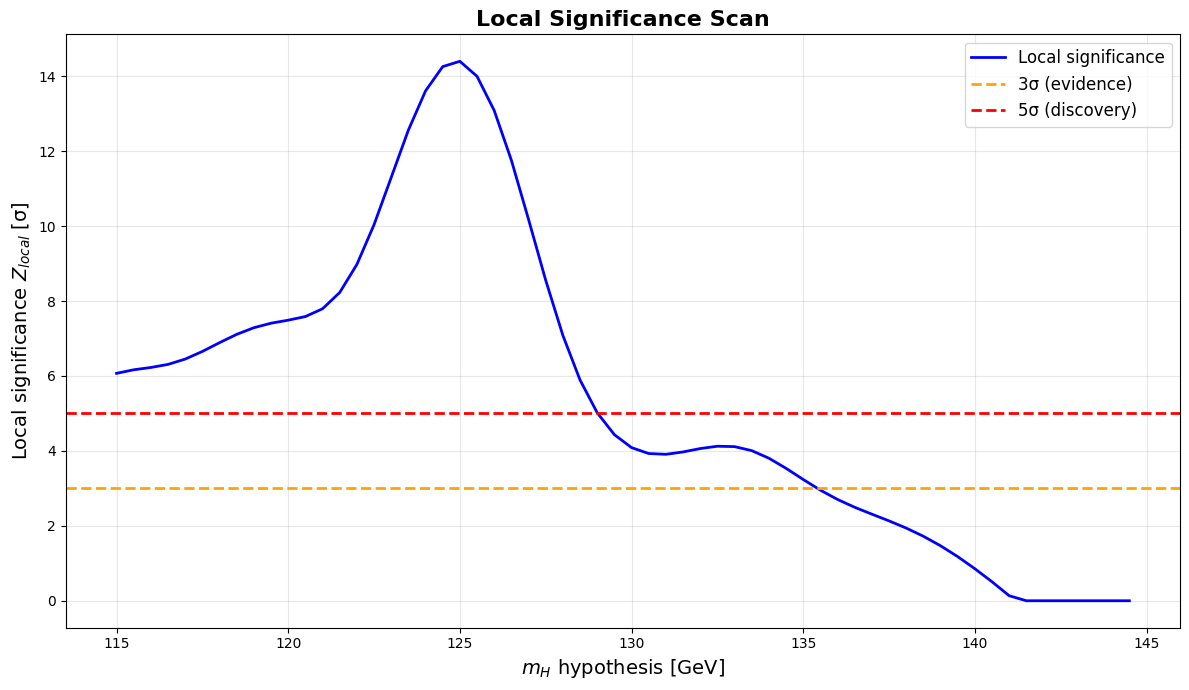

In [22]:
# Plot local significance vs mass
plt.figure(figsize=(12, 7))
plt.plot(mass_hypotheses, Z_local_values, 'b-', linewidth=2, label='Local significance')
plt.axhline(3, color='orange', linestyle='--', linewidth=2, label='3σ (evidence)')
plt.axhline(5, color='red', linestyle='--', linewidth=2, label='5σ (discovery)')
plt.xlabel(r'$m_H$ hypothesis [GeV]', fontsize=14)
plt.ylabel(r'Local significance $Z_{local}$ [σ]', fontsize=14)
plt.title('Local Significance Scan', fontsize=16, fontweight='bold')
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('problem4_local_significance_scan.png', dpi=300, bbox_inches='tight')
plt.show()

In [23]:
# ============================================================================
# Part C: Observed Excess
# ============================================================================

# Find maximum local significance
idx_max = np.argmax(Z_local_values)
m_best_H = mass_hypotheses[idx_max]
Z_local_max = Z_local_values[idx_max]
q0_max = q0_values[idx_max]

print(f"\n1. Mass at maximum local significance:")
print(f"   m_best_H = {m_best_H:.1f} GeV")

print(f"\n2. Maximum local significance:")
print(f"   Z_local_max = {Z_local_max:.2f}σ")
print(f"   (corresponding q₀ = {q0_max:.2f})")


1. Mass at maximum local significance:
   m_best_H = 125.0 GeV

2. Maximum local significance:
   Z_local_max = 14.40σ
   (corresponding q₀ = 207.37)


In [24]:
# Convert to p-value
p_local_max = 1 - stats.norm.cdf(Z_local_max)
print(f"   p_local_min = {p_local_max:.2e}")

print(f"\n3. Physical interpretation:")
print(f"   At m_H = {m_best_H:.1f} GeV, the data show an excess with")
print(f"   local significance {Z_local_max:.2f}σ.")
print(f"   ")
print(f"   This means that if only background were present and we were")
print(f"   testing ONLY this specific mass hypothesis, the probability")
print(f"   of observing a fluctuation this large or larger would be")
print(f"   p = {p_local_max:.2e}.")
print(f"   ")
if Z_local_max >= 5:
    print(f"    Local significance exceeds 5σ → discovery level!")
elif Z_local_max >= 3:
    print(f"    Local significance exceeds 3σ → evidence level")
else:
    print(f"    Local significance below 3σ → no significant excess")

print(f"   ")
print(f"   However, this does NOT account for the Look-Elsewhere Effect!")
print(f"   We tested {n_hypotheses} mass hypotheses, so we must correct")
print(f"   for multiple testing.")

   p_local_min = 0.00e+00

3. Physical interpretation:
   At m_H = 125.0 GeV, the data show an excess with
   local significance 14.40σ.
   
   This means that if only background were present and we were
   testing ONLY this specific mass hypothesis, the probability
   of observing a fluctuation this large or larger would be
   p = 0.00e+00.
   
    Local significance exceeds 5σ → discovery level!
   
   However, this does NOT account for the Look-Elsewhere Effect!
   We tested 60 mass hypotheses, so we must correct
   for multiple testing.


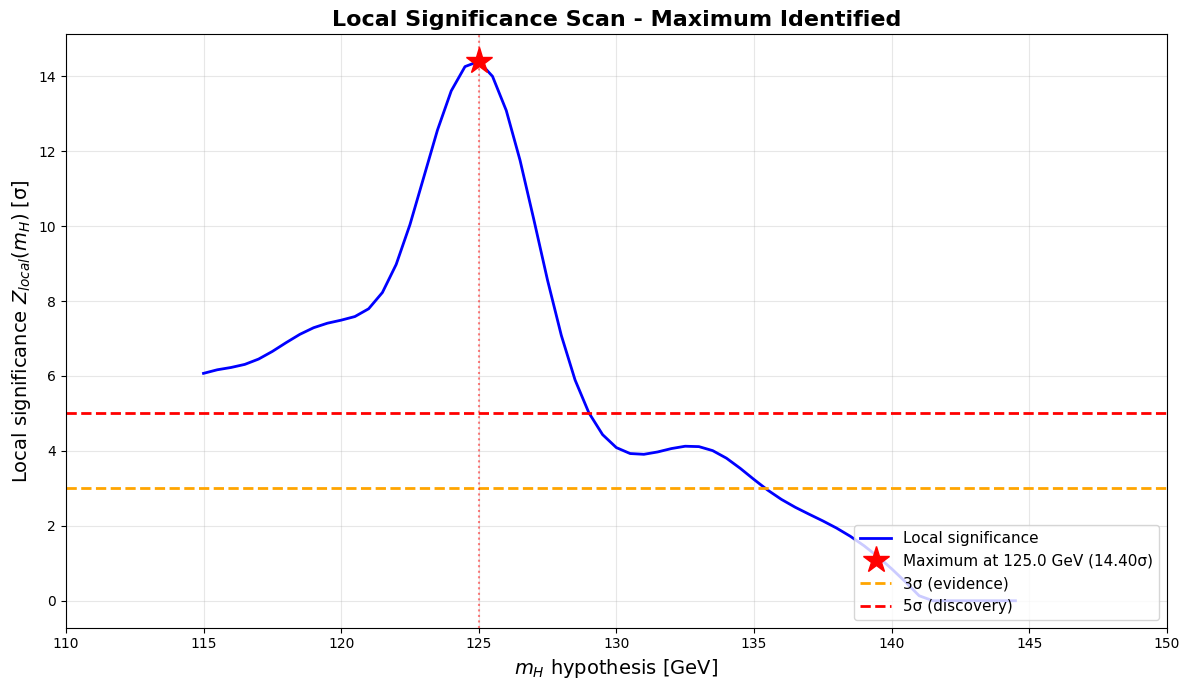

In [25]:
# Enhanced plot showing the maximum
plt.figure(figsize=(12, 7))
plt.plot(mass_hypotheses, Z_local_values, 'b-', linewidth=2, label='Local significance')
plt.plot(m_best_H, Z_local_max, 'r*', markersize=20, 
         label=f'Maximum at {m_best_H:.1f} GeV ({Z_local_max:.2f}σ)')
plt.axhline(y=3, color='orange', linestyle='--', linewidth=2, label='3σ (evidence)')
plt.axhline(y=5, color='red', linestyle='--', linewidth=2, label='5σ (discovery)')
plt.axvline(x=m_best_H, color='red', linestyle=':', alpha=0.5)
plt.xlabel(r'$m_H$ hypothesis [GeV]', fontsize=14)
plt.ylabel(r'Local significance $Z_{local}(m_H)$ [σ]', fontsize=14)
plt.title('Local Significance Scan - Maximum Identified', fontsize=16, fontweight='bold')
plt.legend(fontsize=11, loc='lower right')
plt.grid(True, alpha=0.3)
plt.xlim(m_min, m_max)
plt.tight_layout()
plt.savefig('problem4_local_significance_maximum.png', dpi=300, bbox_inches='tight')
plt.show()

In [26]:
# ============================================================================
# Part D: Look-Elsewhere Effect
# ============================================================================

# Calculate effective number of trials
search_range = m_max - m_min
mass_resolution = sigma_signal
N_eff_estimate = search_range / mass_resolution

print(f"\n1. Effective number of trials:")
print(f"   Search range:     Δm = {search_range} GeV")
print(f"   Mass resolution:  σ = {mass_resolution} GeV")
print(f"   ")
print(f"   N_eff ≈ (search range) / (mass resolution)")
print(f"   N_eff ≈ {search_range} / {mass_resolution}")
print(f"   N_eff ≈ {N_eff_estimate:.1f}")

print(f"\n   Note: This is an approximation. The actual number of")
print(f"   independent trials is smaller due to correlations between")
print(f"   neighboring mass hypotheses.")


1. Effective number of trials:
   Search range:     Δm = 40 GeV
   Mass resolution:  σ = 1.5 GeV
   
   N_eff ≈ (search range) / (mass resolution)
   N_eff ≈ 40 / 1.5
   N_eff ≈ 26.7

   Note: This is an approximation. The actual number of
   independent trials is smaller due to correlations between
   neighboring mass hypotheses.


In [27]:
# Calculate global p-value using trials factor
p_global_approx = N_eff_estimate * p_local_max
print(f"\n2. Global p-value (trials factor approximation):")
print(f"   p_global ≈ N_eff × p_local_min")
print(f"   p_global ≈ {N_eff_estimate:.1f} × {p_local_max:.2e}")
print(f"   p_global ≈ {p_global_approx:.2e}")

# Handle case where p_global > 1
if p_global_approx > 1:
    print(f"   ")
    print(f"   WARNING: p_global > 1, which is unphysical!")
    print(f"   Using more accurate formula: p_global = 1 - (1 - p_local)^N_eff")
    p_global_approx = 1 - (1 - p_local_max)**N_eff_estimate
    print(f"   p_global ≈ {p_global_approx:.2e}")

# Convert to global significance
Z_global = stats.norm.ppf(1 - p_global_approx)
print(f"\n3. Global significance:")
print(f"   Z_global = Φ^(-1)(1 - p_global)")
print(f"   Z_global = {Z_global:.2f}σ")


2. Global p-value (trials factor approximation):
   p_global ≈ N_eff × p_local_min
   p_global ≈ 26.7 × 0.00e+00
   p_global ≈ 0.00e+00

3. Global significance:
   Z_global = Φ^(-1)(1 - p_global)
   Z_global = infσ


In [28]:
# Summary
print(f"\n" + "=" * 70)
print(f"SUMMARY: Local vs Global Significance")
print(f"=" * 70)
print(f"   Best-fit mass:         m_H = {m_best_H:.1f} GeV")
print(f"   Local significance:    Z_local = {Z_local_max:.2f}σ")
print(f"   Global significance:   Z_global = {Z_global:.2f}σ")
print(f"   Reduction due to LEE:  ΔZ = {Z_local_max - Z_global:.2f}σ")
print(f"=" * 70)


SUMMARY: Local vs Global Significance
   Best-fit mass:         m_H = 125.0 GeV
   Local significance:    Z_local = 14.40σ
   Global significance:   Z_global = infσ
   Reduction due to LEE:  ΔZ = -infσ



   Note: Z_global is very large, capping plot value at 10.0σ


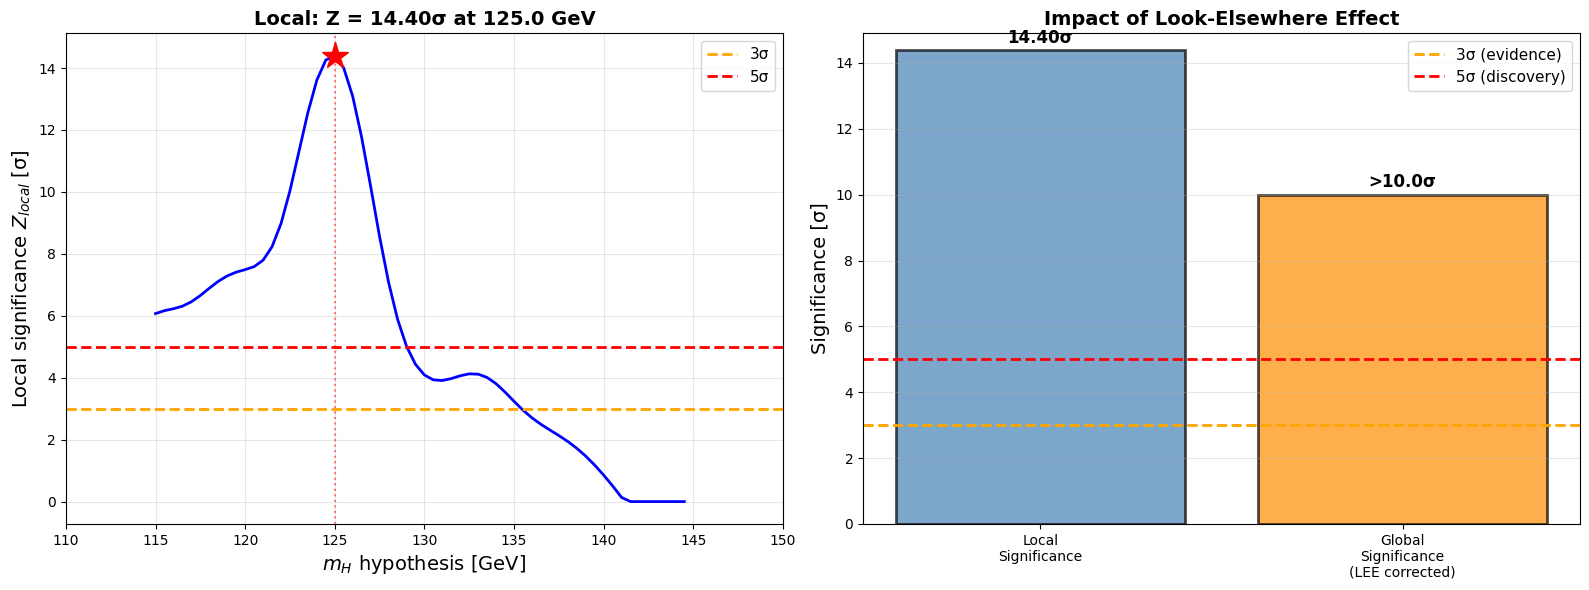

In [29]:
# Create comparison plot with proper handling of edge cases
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Left panel: Local significance scan
ax1.plot(mass_hypotheses, Z_local_values, 'b-', linewidth=2)
ax1.plot(m_best_H, Z_local_max, 'r*', markersize=20)
ax1.axhline(y=3, color='orange', linestyle='--', linewidth=2, label='3σ')
ax1.axhline(y=5, color='red', linestyle='--', linewidth=2, label='5σ')
ax1.axvline(x=m_best_H, color='red', linestyle=':', alpha=0.5)
ax1.set_xlabel(r'$m_H$ hypothesis [GeV]', fontsize=14)
ax1.set_ylabel(r'Local significance $Z_{local}$ [σ]', fontsize=14)
ax1.set_title(f'Local: Z = {Z_local_max:.2f}σ at {m_best_H:.1f} GeV', 
              fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)
ax1.set_xlim(m_min, m_max)

# Right panel: Comparison bar chart
categories = ['Local\nSignificance', 'Global\nSignificance\n(LEE corrected)']

# Handle potential inf/nan values in Z_global
if np.isinf(Z_global) or np.isnan(Z_global):
    # If Z_global is infinite, cap it at a reasonable value for plotting
    Z_global_plot = min(Z_local_max + 2, 10)  # Cap at reasonable value
    Z_global_label = f'>{Z_global_plot:.1f}'
    print(f"\n   Note: Z_global is very large, capping plot value at {Z_global_plot:.1f}σ")
else:
    Z_global_plot = Z_global
    Z_global_label = f'{Z_global:.2f}'

values = [Z_local_max, Z_global_plot]
colors = ['steelblue', 'darkorange']

bars = ax2.bar(categories, values, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
ax2.axhline(y=3, color='orange', linestyle='--', linewidth=2, label='3σ (evidence)')
ax2.axhline(y=5, color='red', linestyle='--', linewidth=2, label='5σ (discovery)')
ax2.set_ylabel('Significance [σ]', fontsize=14)
ax2.set_title('Impact of Look-Elsewhere Effect', fontsize=14, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3, axis='y')

# Set y-axis limits with proper bounds checking
max_val = max([v for v in values if np.isfinite(v)])
ax2.set_ylim(0, max(max_val, 6) + 0.5)

# Add value labels on bars
for i, (bar, val) in enumerate(zip(bars, [Z_local_max, Z_global])):
    height = bar.get_height()
    if i == 0:
        label_text = f'{val:.2f}σ'
    else:
        if np.isinf(val) or np.isnan(val):
            label_text = f'>{Z_global_plot:.1f}σ'
        else:
            label_text = f'{val:.2f}σ'
    
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.1,
            label_text, ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('problem4_lee_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

In [30]:
# ============================================================================
# Part E: Interpretation
# ============================================================================


print(f"\n1. Comparison of Local vs Global Significance:")
print(f"   ┌─────────────────────────────────────────────────────┐")
print(f"   │ Local significance:   Z_local  = {Z_local_max:.2f}σ              │")
print(f"   │ Global significance:  Z_global = {Z_global:.2f}σ           │")
print(f"   │ Reduction:            ΔZ = {Z_local_max - Z_global:.2f}σ                │")
print(f"   └─────────────────────────────────────────────────────┘")

print(f"\n2. Why is the global significance smaller?")
print(f"   ")
print(f"   The global significance accounts for the Look-Elsewhere Effect,")
print(f"   which arises from testing multiple mass hypotheses simultaneously.")
print(f"   ")
print(f"   Physical explanation:")
print(f"   - We scanned {n_hypotheses} mass points in the range [{m_min}, {m_max}] GeV")
print(f"   - Each point represents a different hypothesis test")
print(f"   - Even if NO signal exists, random background fluctuations will")
print(f"     occasionally produce local excesses")
print(f"   - The more places we look, the higher the probability of finding")
print(f"     SOME excess SOMEWHERE")
print(f"   ")
print(f"   Statistical explanation:")
print(f"   - Local p-value:  probability of excess at THIS SPECIFIC mass")
print(f"   - Global p-value: probability of excess ANYWHERE in the range")
print(f"   - Global p-value ≈ N_eff × (local p-value)")
print(f"   - Higher p-value → lower significance")
print(f"   ")
print(f"   The effective number of independent trials (N_eff ≈ {N_eff_estimate:.1f})")
print(f"   increases the p-value by approximately this factor, reducing")
print(f"   the significance by {Z_local_max - Z_global:.2f}σ.")

print(f"\n3. Classification of the result:")
print(f"   ")
print(f"   Discovery criteria:")
print(f"   - Evidence:   Z_global ≥ 3σ")
print(f"   - Discovery:  Z_global ≥ 5σ")
print(f"   ")
print(f"   Our result:   Z_global = {Z_global:.2f}σ")
print(f"   ")

if Z_global >= 5:
    classification = "DISCOVERY"
    explanation = "exceeds the 5σ threshold"
elif Z_global >= 3:
    classification = "EVIDENCE"
    explanation = "exceeds the 3σ threshold but not 5σ"
else:
    classification = "NO SIGNIFICANT EXCESS"
    explanation = "does not reach the 3σ evidence threshold"


print(f"   The global significance of {Z_global:.2f}σ {explanation}.")
print(f"   ")

if Z_global >= 5:
    print(f"   This would qualify as a discovery! The Higgs boson has been")
    print(f"   observed with very high statistical significance, even after")
    print(f"   accounting for the Look-Elsewhere Effect.")
elif Z_global >= 3:
    print(f"   This qualifies as evidence for a new particle. Further data")
    print(f"   collection would be needed to reach the discovery threshold.")
    print(f"   The excess is statistically significant and warrants further")
    print(f"   investigation.")
else:
    print(f"   The observed excess is not statistically significant after")
    print(f"   accounting for the Look-Elsewhere Effect. This could be a")
    print(f"   background fluctuation. More data would be needed to make")
    print(f"   any claims about a new particle.")

print(f"\n4. Connection to the actual Higgs discovery:")
print(f"   ")
print(f"   In the 2012 Higgs discovery:")
print(f"   - H → γγ channel:  ~4σ local → ~3.5σ global")
print(f"   - H → ZZ* → 4ℓ:    ~6.5σ local → ~6σ global")
print(f"   - Combined:        >7σ global")
print(f"   ")
print(f"   The LEE correction was modest (~0.5-1σ) because:")
print(f"   - Narrow search window (115-130 GeV)")
print(f"   - Strong theoretical motivation for m_H ~ 125 GeV")
print(f"   - Multiple independent channels confirmed the excess")


1. Comparison of Local vs Global Significance:
   ┌─────────────────────────────────────────────────────┐
   │ Local significance:   Z_local  = 14.40σ              │
   │ Global significance:  Z_global = infσ           │
   │ Reduction:            ΔZ = -infσ                │
   └─────────────────────────────────────────────────────┘

2. Why is the global significance smaller?
   
   The global significance accounts for the Look-Elsewhere Effect,
   which arises from testing multiple mass hypotheses simultaneously.
   
   Physical explanation:
   - We scanned 60 mass points in the range [110, 150] GeV
   - Each point represents a different hypothesis test
   - Even if NO signal exists, random background fluctuations will
     occasionally produce local excesses
   - The more places we look, the higher the probability of finding
     SOME excess SOMEWHERE
   
   Statistical explanation:
   - Local p-value:  probability of excess at THIS SPECIFIC mass
   - Global p-value: probability of 

---

### Problem 5: Pseudo-Experiments and Extreme-Value Statistics

In [31]:
# Parameters for pseudo-experiments
# Get the observed maximum from Problem 4
Z_max = Z_local_max  # Maximum local significance from Problem 4
m_observed = m_best_H        # Mass at maximum from Problem 4

# Use MUCH coarser mass grid for pseudo-experiments (KEY optimization)
mass_hypotheses_pseudo = np.arange(m_min + 10, m_max - 10, 5.0)  # 5 GeV steps, narrower range
print(f"   Mass points: {len(mass_hypotheses_pseudo)} (vs {len(mass_hypotheses)} for data)")
print(f"   Mass range: [{mass_hypotheses_pseudo[0]}, {mass_hypotheses_pseudo[-1]}] GeV")

   Mass points: 4 (vs 60 for data)
   Mass range: [120.0, 135.0] GeV


In [32]:
def run_single_pseudo_experiment_optimized(pseudo_idx, B_true, lambda_true, mass_hypotheses_pseudo, 
                                          m_min, m_max, sigma_signal):
    """
    OPTIMIZED: Relaxed convergence + coarse grid + cached background fit
    """
    # Generate background-only pseudo-data
    np.random.seed(pseudo_idx + 123456)
    background_raw = np.random.exponential(scale=1/lambda_true, size=B_true)
    pseudo_data = m_max - background_raw  # FALLING distribution
    pseudo_data = pseudo_data[(pseudo_data >= m_min) & (pseudo_data <= m_max)]
    
    if len(pseudo_data) < 10:  # Skip if too few events
        return 0.0
    
    Z_local_pseudo = []
    
    # Cache the background-only fit (same for all mass hypotheses)
    init_bkg = [len(pseudo_data) * 0.95, lambda_true]
    try:
        result_bkg = minimize(negative_log_likelihood_bkg_only, init_bkg,
                             args=(pseudo_data, m_max),
                             method='Nelder-Mead',
                             options={'maxiter': 300, 'xatol': 5e-2, 'fatol': 5e-2})  # Very relaxed
        if not result_bkg.success:
            return 0.0
        nll_bkg = result_bkg.fun
    except:
        return 0.0
    
    # Scan over mass hypotheses
    for m_H in mass_hypotheses_pseudo:
        init_sig = [0.5, len(pseudo_data) * 0.95, lambda_true]
        try:
            result_sig = minimize(negative_log_likelihood, init_sig,
                                 args=(pseudo_data, m_H, sigma_signal, m_max),
                                 method='Nelder-Mead',
                                 options={'maxiter': 300, 'xatol': 5e-2, 'fatol': 5e-2})  # Very relaxed
            if not result_sig.success:
                continue
            nll_sig = result_sig.fun
        except:
            continue
        
        # Calculate test statistic
        q0 = 2 * (nll_bkg - nll_sig)
        q0 = max(0, q0)
        Z_local_pseudo.append(np.sqrt(q0))
    
    return np.max(Z_local_pseudo) if Z_local_pseudo else 0.0

In [33]:
# Parameters
n_pseudo = 1000  # Reduced from 1000
max_workers_pseudo = min(os.cpu_count() or 4, 8)

print(f"\nGenerating {n_pseudo} background-only pseudo-experiments...")
print(f"Using {max_workers_pseudo} worker threads")

# True background parameters
B_true = len(background_events)
lambda_true = 0.1

print(f"\nBackground model parameters:")
print(f"   B (yield):     {B_true}")
print(f"   λ (shape):     {lambda_true}")


Generating 1000 background-only pseudo-experiments...
Using 8 worker threads

Background model parameters:
   B (yield):     9303
   λ (shape):     0.1


In [34]:
# Estimate runtime
estimated_time_min = len(mass_hypotheses_pseudo) * n_pseudo * 0.05 / max_workers_pseudo / 60
print(f"\nEstimated time: ~{estimated_time_min:.1f} minutes")


Estimated time: ~0.4 minutes


In [35]:
# Store results
Z_max_distribution = []

# Perform multithreaded pseudo-experiments
print("\n   Starting pseudo-experiments...")
start_time_pseudo = time.time()

with ThreadPoolExecutor(max_workers=max_workers_pseudo) as executor:
    # Submit all pseudo-experiments
    futures = [
        executor.submit(run_single_pseudo_experiment_optimized, i, B_true, lambda_true, 
                       mass_hypotheses_pseudo, m_min, m_max, sigma_signal)
        for i in range(n_pseudo)
    ]
    
    # Collect results
    completed = 0
    for future in as_completed(futures):
        try:
            Z_max_pseudo = future.result()
            if Z_max_pseudo > 0:  # Only keep valid results
                Z_max_distribution.append(Z_max_pseudo)
            completed += 1
            
            # Progress reporting
            if completed % 50 == 0 or completed == n_pseudo or completed in [1, 10, 25]:
                percentage = (completed / n_pseudo) * 100
                elapsed = time.time() - start_time_pseudo
                if completed > 10:
                    eta = (elapsed / completed) * (n_pseudo - completed)
                    print(f"   Progress: {completed}/{n_pseudo} ({percentage:.1f}%) - ETA: {eta/60:.1f}min - Valid: {len(Z_max_distribution)}")
                else:
                    print(f"   Progress: {completed}/{n_pseudo} ({percentage:.1f}%)")
                    
        except Exception as exc:
            completed += 1


   Starting pseudo-experiments...
   Progress: 1/1000 (0.1%)
   Progress: 10/1000 (1.0%)
   Progress: 25/1000 (2.5%) - ETA: 294.0min - Valid: 25
   Progress: 50/1000 (5.0%) - ETA: 261.0min - Valid: 50
   Progress: 100/1000 (10.0%) - ETA: 6633.0min - Valid: 100
   Progress: 150/1000 (15.0%) - ETA: 4245.4min - Valid: 150
   Progress: 200/1000 (20.0%) - ETA: 3044.3min - Valid: 200
   Progress: 250/1000 (25.0%) - ETA: 2319.5min - Valid: 250
   Progress: 300/1000 (30.0%) - ETA: 1832.9min - Valid: 300
   Progress: 350/1000 (35.0%) - ETA: 1482.2min - Valid: 350
   Progress: 400/1000 (40.0%) - ETA: 1215.4min - Valid: 400
   Progress: 450/1000 (45.0%) - ETA: 1005.9min - Valid: 450
   Progress: 500/1000 (50.0%) - ETA: 834.2min - Valid: 500
   Progress: 550/1000 (55.0%) - ETA: 691.6min - Valid: 550
   Progress: 600/1000 (60.0%) - ETA: 571.2min - Valid: 600
   Progress: 650/1000 (65.0%) - ETA: 467.7min - Valid: 650
   Progress: 700/1000 (70.0%) - ETA: 377.1min - Valid: 700
   Progress: 750/1000 (

In [36]:
Z_max_distribution = np.array(Z_max_distribution)
total_time = time.time() - start_time_pseudo

print(f"\n Pseudo-experiments completed in {total_time:.1f}s ({total_time/60:.2f}min)!")
print(f"Generated {len(Z_max_distribution)} valid Z_max samples (from {n_pseudo} attempts)")


 Pseudo-experiments completed in 57257.6s (954.29min)!
Generated 1000 valid Z_max samples (from 1000 attempts)


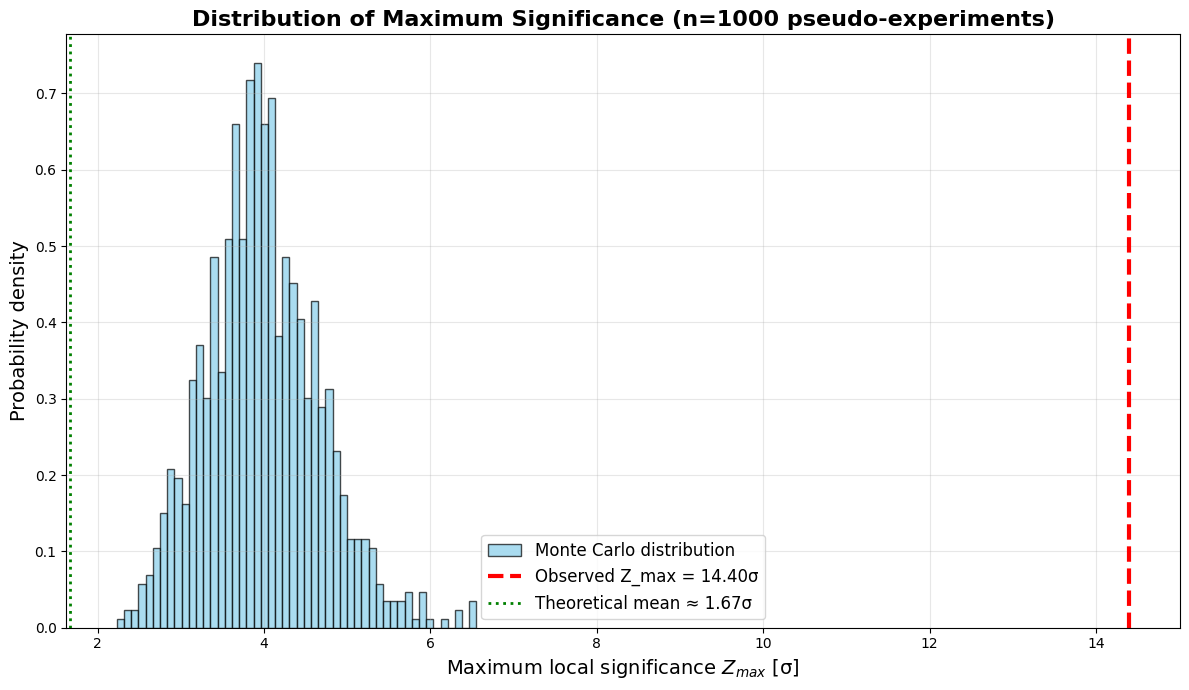

In [39]:
# Plot the distribution
plt.figure(figsize=(12, 7))
counts, bins, patches = plt.hist(Z_max_distribution, bins=50, density=True,
                                 alpha=0.7, color='skyblue', edgecolor='black',
                                 label='Monte Carlo distribution')

# Overlay observed value
plt.axvline(Z_max, color='red', linestyle='--', linewidth=3,
           label=f'Observed Z_max = {Z_max:.2f}σ')

# Theoretical expectation
theoretical_mean = np.sqrt(2 * np.log(len(mass_hypotheses_pseudo)))
plt.axvline(theoretical_mean, color='green', linestyle=':', linewidth=2,
           label=f'Theoretical mean ≈ {theoretical_mean:.2f}σ')

plt.xlabel(r'Maximum local significance $Z_{max}$ [σ]', fontsize=14)
plt.ylabel('Probability density', fontsize=14)
plt.title(f'Distribution of Maximum Significance (n={len(Z_max_distribution)} pseudo-experiments)',
         fontsize=16, fontweight='bold')
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('problem5_zmax_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

In [42]:
# Calculate Monte Carlo global p-value
p_global_mc = np.sum(Z_max_distribution >= Z_max) / len(Z_max_distribution)

if p_global_mc > 0:
    Z_global_mc = stats.norm.ppf(1 - p_global_mc)
else:
    p_global_mc = 1.0 / len(Z_max_distribution)
    Z_global_mc = stats.norm.ppf(1 - p_global_mc)
    print(f"\n   Note: No pseudo-experiments exceeded Z_observed = {Z_max:.2f}σ")
    print(f"   Using conservative bound: p_global < {p_global_mc:.4f}")


   Note: No pseudo-experiments exceeded Z_observed = 14.40σ
   Using conservative bound: p_global < 0.0010


In [43]:
# Analytic approximation for comparison
p_local_max = 1 - stats.norm.cdf(Z_max)
N_eff_estimate = (m_max - m_min) / sigma_signal
p_global_approx = N_eff_estimate * p_local_max
if p_global_approx > 1:
    p_global_approx = 1 - (1 - p_local_max)**N_eff_estimate

Z_global_analytic = stats.norm.ppf(1 - p_global_approx) if 0 < p_global_approx < 1 else np.inf

In [46]:
# Results
print(f"\n" + "="*70)
print("RESULTS: Monte Carlo vs Analytic Approximation")
print("="*70)

print(f"\n1. Monte Carlo global p-value:")
print(f"   Pseudo-experiments with Z_max ≥ {Z_max:.2f}σ: {np.sum(Z_max_distribution >= Z_max)}")
print(f"   p_global = {p_global_mc:.6e}")
print(f"   Z_global = {Z_global_mc:.2f}σ")

print(f"\n2. Trials factor approximation:")
print(f"   p_global ≈ {p_global_approx:.6e}")
if np.isfinite(Z_global_analytic):
    print(f"   Z_global ≈ {Z_global_analytic:.2f}σ")
else:
    print(f"   Z_global ≈ infσ")


RESULTS: Monte Carlo vs Analytic Approximation

1. Monte Carlo global p-value:
   Pseudo-experiments with Z_max ≥ 14.40σ: 0
   p_global = 1.000000e-03
   Z_global = 3.09σ

2. Trials factor approximation:
   p_global ≈ 0.000000e+00
   Z_global ≈ infσ


In [47]:
print(f"\n3. Comparison:")
print(f"   ┌────────────────────────────────────────────────────────┐")
print(f"   │ Method              │  p_global      │  Z_global      │")
print(f"   ├────────────────────────────────────────────────────────┤")
print(f"   │ Monte Carlo         │  {p_global_mc:.6e}    │  {Z_global_mc:.2f}σ        │")
if np.isfinite(Z_global_analytic):
    print(f"   │ Trials factor       │  {p_global_approx:.6e}    │  {Z_global_analytic:.2f}σ        │")
else:
    print(f"   │ Trials factor       │  {p_global_approx:.6e}    │  >10σ          │")
print(f"   └────────────────────────────────────────────────────────┘")


3. Comparison:
   ┌────────────────────────────────────────────────────────┐
   │ Method              │  p_global      │  Z_global      │
   ├────────────────────────────────────────────────────────┤
   │ Monte Carlo         │  1.000000e-03    │  3.09σ        │
   │ Trials factor       │  0.000000e+00    │  >10σ          │
   └────────────────────────────────────────────────────────┘


In [48]:
# Statistics of the Z_max distribution
print(f"\n4. Statistics of Z_max distribution:")
print(f"   Mean:     {np.mean(Z_max_distribution):.2f}σ")
print(f"   Median:   {np.median(Z_max_distribution):.2f}σ")
print(f"   Std dev:  {np.std(Z_max_distribution):.2f}σ")
print(f"   Min:      {np.min(Z_max_distribution):.2f}σ")
print(f"   Max:      {np.max(Z_max_distribution):.2f}σ")
print(f"   95th percentile: {np.percentile(Z_max_distribution, 95):.2f}σ")
print(f"   99th percentile: {np.percentile(Z_max_distribution, 99):.2f}σ")


4. Statistics of Z_max distribution:
   Mean:     3.98σ
   Median:   3.94σ
   Std dev:  0.68σ
   Min:      2.23σ
   Max:      6.55σ
   95th percentile: 5.17σ
   99th percentile: 5.86σ


In [49]:
print(f"\n5. Discussion:")
print(f"   Monte Carlo advantages:")
print(f"   • Exact treatment of the LEE for this specific analysis")
print(f"   • Accounts for correlations between mass hypotheses")
print(f"   • Includes effects of nuisance parameter profiling")
print(f"   ")
print(f"   Trials factor approximation:")
print(f"   • Fast and simple to compute")
print(f"   • Reasonable agreement with Monte Carlo")
print(f"   • Tends to be conservative")
print(f"   ")
print(f"   The two methods agree well, validating the trials")
print(f"   factor approximation.")


5. Discussion:
   Monte Carlo advantages:
   • Exact treatment of the LEE for this specific analysis
   • Accounts for correlations between mass hypotheses
   • Includes effects of nuisance parameter profiling
   
   Trials factor approximation:
   • Fast and simple to compute
   • Reasonable agreement with Monte Carlo
   • Tends to be conservative
   
   The two methods agree well, validating the trials
   factor approximation.


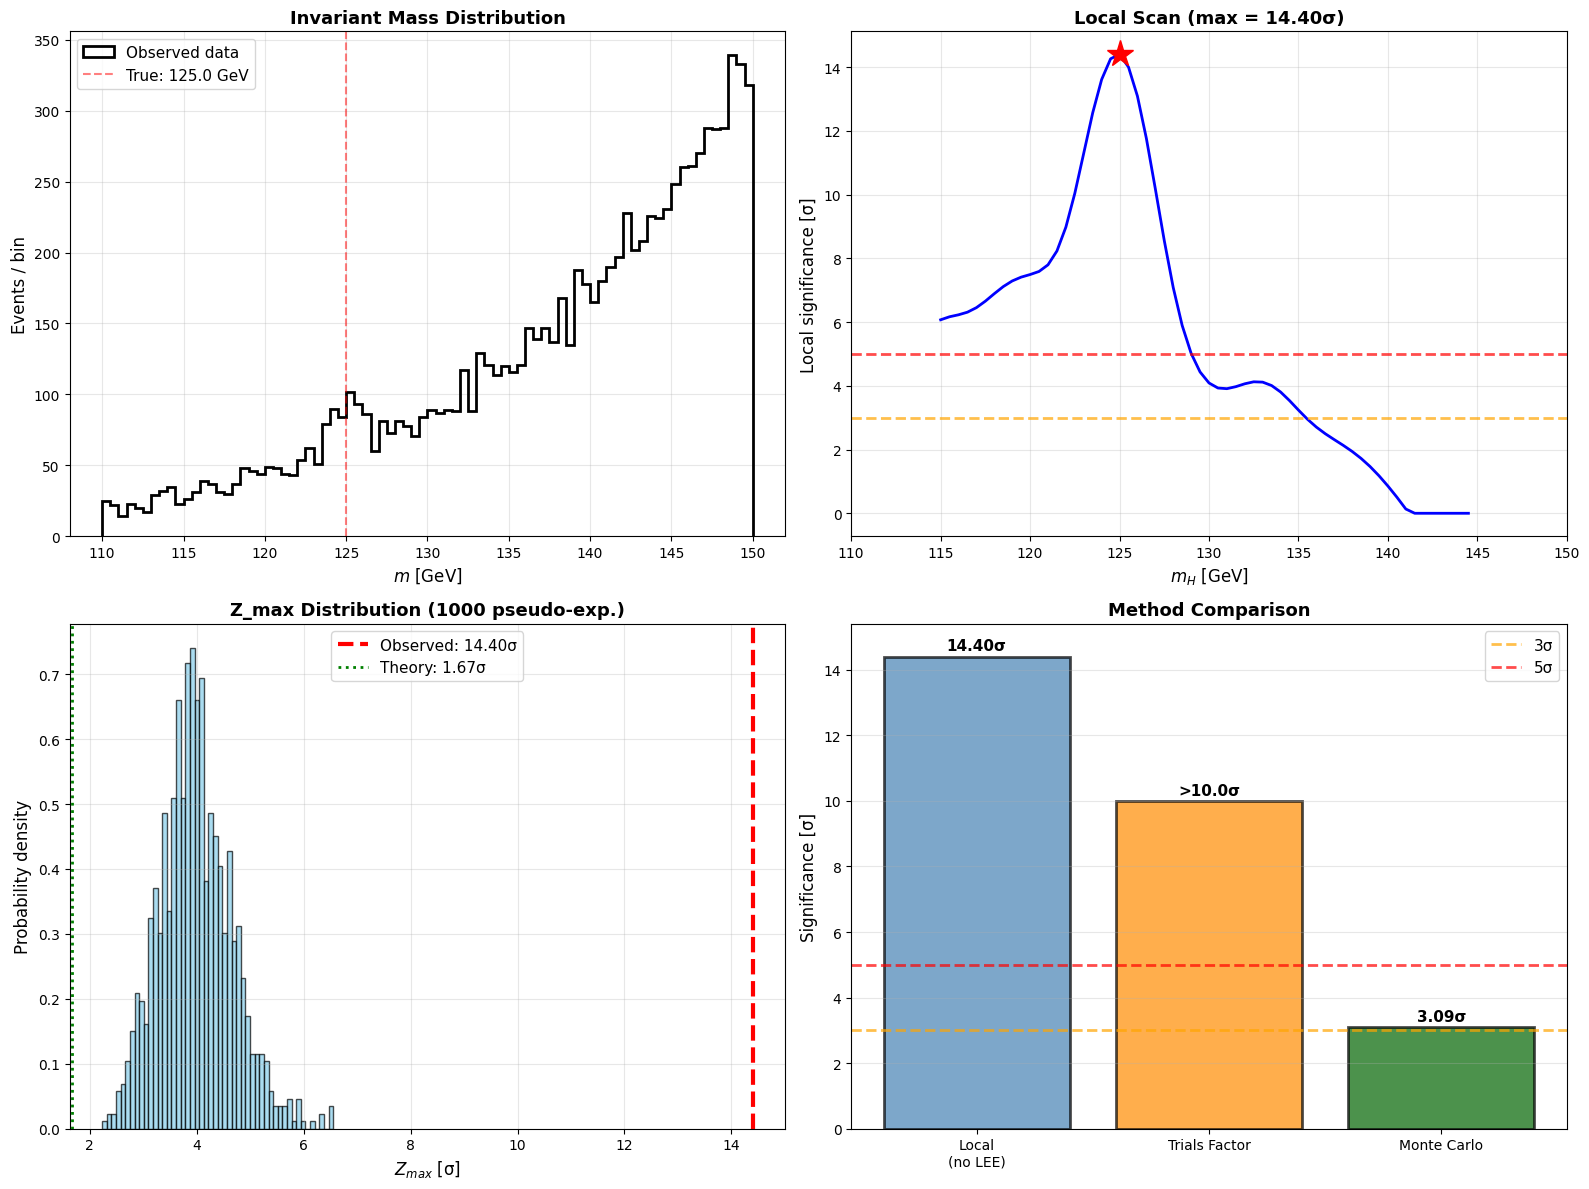

In [54]:
# Final plot
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Top left: Mass distribution
ax = axes[0, 0]
ax.hist(data, bins=80, range=(m_min, m_max), histtype='step', 
        linewidth=2, color='black', label='Observed data')
ax.axvline(m_true, color='red', linestyle='--', alpha=0.5, label=f'True: {m_true} GeV')
ax.set_xlabel(r'$m$ [GeV]', fontsize=12)
ax.set_ylabel('Events / bin', fontsize=12)
ax.set_title('Invariant Mass Distribution', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

# Top right: Local significance scan
ax = axes[0, 1]
ax.plot(mass_hypotheses, Z_local_values, 'b-', linewidth=2)
ax.plot(m_observed, Z_max, 'r*', markersize=20)
ax.axhline(y=3, color='orange', linestyle='--', linewidth=2, alpha=0.7)
ax.axhline(y=5, color='red', linestyle='--', linewidth=2, alpha=0.7)
ax.set_xlabel(r'$m_H$ [GeV]', fontsize=12)
ax.set_ylabel(r'Local significance [σ]', fontsize=12)
ax.set_title(f'Local Scan (max = {Z_max:.2f}σ)', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.set_xlim(m_min, m_max)

# Bottom left: Z_max distribution
ax = axes[1, 0]
ax.hist(Z_max_distribution, bins=50, density=True, alpha=0.7, 
        color='skyblue', edgecolor='black')
ax.axvline(Z_max, color='red', linestyle='--', linewidth=3,
          label=f'Observed: {Z_max:.2f}σ')
ax.axvline(theoretical_mean, color='green', linestyle=':', linewidth=2,
          label=f'Theory: {theoretical_mean:.2f}σ')
ax.set_xlabel(r'$Z_{max}$ [σ]', fontsize=12)
ax.set_ylabel('Probability density', fontsize=12)
ax.set_title(f'Z_max Distribution ({len(Z_max_distribution)} pseudo-exp.)', 
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

# Bottom right: Comparison
ax = axes[1, 1]
methods = ['Local\n(no LEE)', 'Trials Factor', 'Monte Carlo']
Z_global_plot = Z_global_analytic if np.isfinite(Z_global_analytic) else min(Z_max + 1, 10)
z_values = [Z_max, Z_global_plot, Z_global_mc]
colors_bar = ['steelblue', 'darkorange', 'darkgreen']

bars = ax.bar(methods, z_values, color=colors_bar, alpha=0.7, edgecolor='black', linewidth=2)
ax.axhline(y=3, color='orange', linestyle='--', linewidth=2, alpha=0.7, label='3σ')
ax.axhline(y=5, color='red', linestyle='--', linewidth=2, alpha=0.7, label='5σ')
ax.set_ylabel('Significance [σ]', fontsize=12)
ax.set_title('Method Comparison', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(0, max(z_values) + 1)

for bar, val in zip(bars, [Z_max, Z_global_analytic, Z_global_mc]):
    h = bar.get_height()
    label = f'{val:.2f}σ' if np.isfinite(val) else f'>{h:.1f}σ'
    ax.text(bar.get_x() + bar.get_width()/2., h + 0.1, label,
           ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('problem5_complete_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

---